Training samples: (60000, 28, 28)
Test samples    : (10000, 28, 28)

Training the discriminative classifier...
Epoch 1/3
422/422 [==============================] - 1s 1ms/step - loss: 0.3770 - accuracy: 0.8976 - val_loss: 0.1664 - val_accuracy: 0.9550
Epoch 2/3
422/422 [==============================] - 0s 954us/step - loss: 0.1754 - accuracy: 0.9494 - val_loss: 0.1240 - val_accuracy: 0.9658
Epoch 3/3
422/422 [==============================] - 0s 957us/step - loss: 0.1266 - accuracy: 0.9634 - val_loss: 0.1011 - val_accuracy: 0.9707

Classifier accuracy: 0.965399980545044

Training the generative autoencoder...
Epoch 1/3
422/422 [==============================] - 1s 2ms/step - loss: 0.0453 - val_loss: 0.0245
Epoch 2/3
422/422 [==============================] - 1s 2ms/step - loss: 0.0200 - val_loss: 0.0167
Epoch 3/3
1/1 [==============================] - 0s 47ms/step


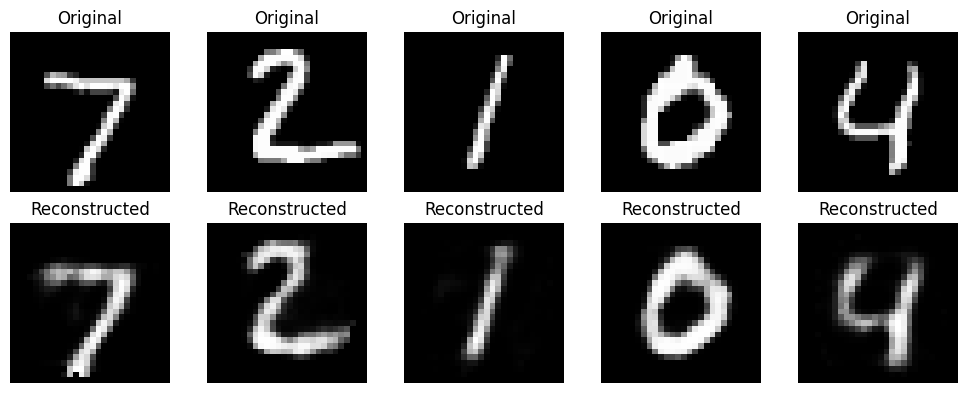

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape

# 1. Load and Normalize MNIST

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training samples:", x_train.shape)
print("Test samples    :", x_test.shape)


# 2. Discriminative Model (Classifier)

discriminator_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

discriminator_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining the discriminative classifier...")
discriminator_model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=128,
                        validation_split=0.1)

loss, acc = discriminator_model.evaluate(x_test, y_test, verbose=0)
print("\nClassifier accuracy:", acc)


# 3. Generative Model (Autoencoder)

generator_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),   # encoder layer
    Dense(32, activation="relu"),    # bottleneck layer
    Dense(128, activation="relu"),   # decoder layer
    Dense(784, activation="sigmoid"),
    Reshape((28, 28))
])

generator_model.compile(optimizer="adam", loss="mse")

print("\nTraining the generative autoencoder...")
generator_model.fit(x_train, x_train,
                    epochs=3,
                    batch_size=128,
                    validation_split=0.1)


# 4. Reconstruct Test Images

reconstructed_images = generator_model.predict(x_test[:5])


# 5. Visualize Original vs Generated

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed_images[i], cmap="gray")
    plt.axis("off")
    plt.title("Reconstructed")

plt.tight_layout()
plt.show()